<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/Pratica_3/DSP_1_PRATICA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prática 3 Exercício 1

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_957/2591885157.py:27: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Parte Real ($\sigma$)')
/tmp/ipykernel_957/2591885157.py:28: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Parte Imaginária ($j\omega$)')


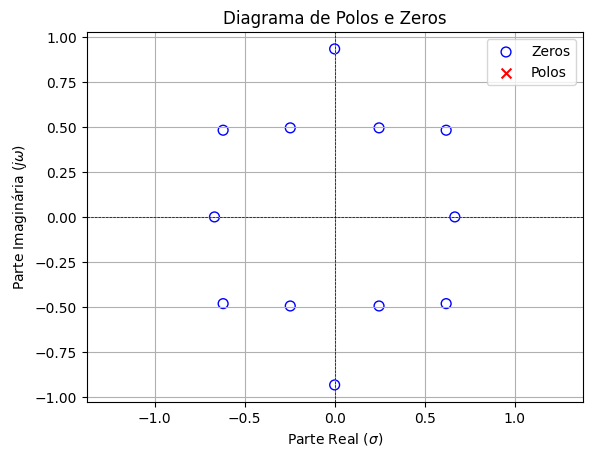

In [ ]:
import numpy as np
import matplotlib.pyplot as plot
from scipy import signal

num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
den = [1]

w = np.logspace (-1, 10, 200)

w_out, H = signal.freqresp((num, den), w)

magnitude = np.abs(H)
fase = np.angle(H, deg = True)

#ZEROS E POLOS
zeros, polos, k = signal.tf2zpk(num, den)

fig, ax = plt.subplots()

ax.scatter (np.real(zeros), np.imag(zeros), s = 50, marker = 'o', facecolors = 'none', edgecolors = 'b', label = 'Zeros')
ax.scatter (np.real(polos), np.imag(polos), s = 50, marker = 'x', color = 'r', label = 'Polos')

ax.axhline (y = 0, color = 'k', linestyle = '--', linewidth = 0.5)
ax.axvline (x = 0, color = 'k', linestyle = '--', linewidth = 0.5)

ax.set_title('Diagrama de Polos e Zeros')
ax.set_xlabel('Parte Real ($\sigma$)')
ax.set_ylabel('Parte Imaginária ($j\omega$)')
ax.grid(True)
ax.legend()
ax.axis('equal')

plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_957/1348085257.py:33: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')


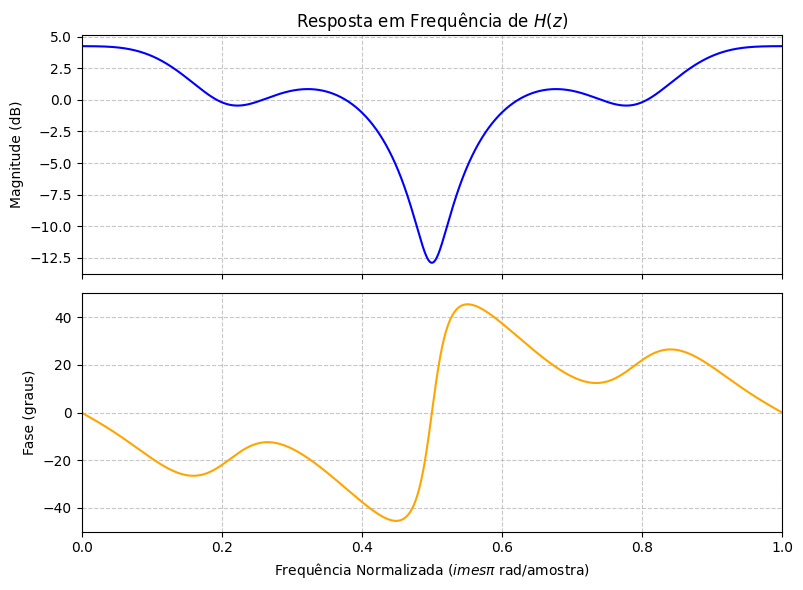

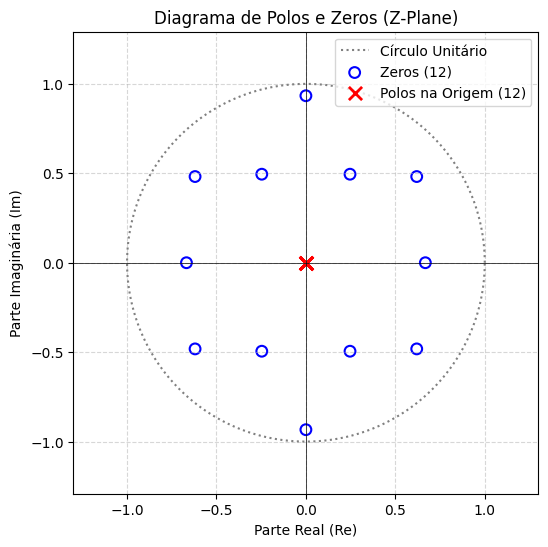

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes originais do numerador de z^12 até z^0
num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]

# Denominador correspondente a z^12 (1 seguido de 12 zeros)
den = [1] + [0] * 12

# Resposta em frequencia
# Calcula a resposta em frequência (w em rad/amostra, H é complexo)
# worN=8000 define a resolução do gráfico (8000 pontos)
w, H = signal.freqz(num, den, worN=8000)

# Extrai Magnitude (em decibéis) e Fase (em graus)
magnitude_db = 20 * np.log10(np.abs(H))
fase_graus = np.degrees(np.unwrap(np.angle(H)))

# --- Plotando os Gráficos ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 1. Gráfico de Magnitude
ax1.plot(w / np.pi, magnitude_db, color='blue', linewidth=1.5)
ax1.set_title('Resposta em Frequência de $H(z)$')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfico de Fase
ax2.plot(w / np.pi, fase_graus, color='orange', linewidth=1.5)
ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')
ax2.set_ylabel('Fase (graus)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajusta o eixo X para ir de 0 a 1 (0 a pi rad)
ax2.set_xlim([0, 1])

plt.tight_layout()

#CALCULOS DE POLOS DE ZEROS

# Calcula analiticamente todos os zeros e polos exatos
zeros, polos, k = signal.tf2zpk(num, den)

# Cria a figura
fig, ax = plt.subplots(figsize=(6, 6))

# 1. Desenha o Círculo Unitário (Filtros Digitais / Tempo Discreto)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# 2. Plota os Zeros (como circunferências 'o')
ax.scatter(np.real(zeros), np.imag(zeros), s=60, marker='o',
           facecolors='none', edgecolors='blue', linewidth=1.5, label=f'Zeros ({len(zeros)})')

# 3. Plota os Polos (como 'x' vermelhos) -> Agora os 12 polos em (0,0) vão aparecer!
ax.scatter(np.real(polos), np.imag(polos), s=90, marker='x',
           color='red', linewidth=2, label=f'Polos na Origem ({len(polos)})')

# Ajustes de layout e eixos cruzados na origem
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax.set_title('Diagrama de Polos e Zeros (Z-Plane)')
ax.set_xlabel('Parte Real (Re)')
ax.set_ylabel('Parte Imaginária (Im)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Garante proporção 1:1 perfeita para o círculo não virar uma elipse
ax.axis('equal')

# Define limites ligeiramente maiores que o círculo unitário para melhor visualização
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])

plt.show()

Pratica 3 Exercício 2


 arquivo de handel.wav 




 gráfico do handel.wav 



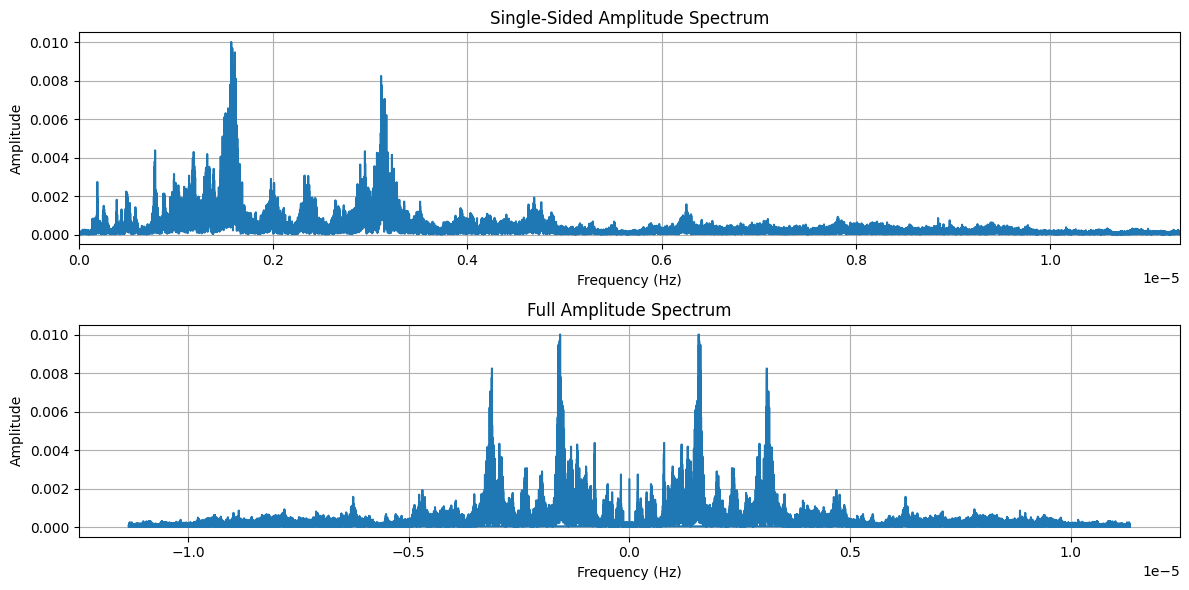

ValueError: volume and kernel should have the same dimensionality

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq
from scipy.signal import convolve

fs= 1/44100

# Coeficientes originais do numerador de z^12 até z^0
num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]

# Denominador correspondente a z^12 (1 seguido de 12 zeros)
den = [1] + [0] * 12

H = signal.freqz(num, den, worN=8000)

print ('\n arquivo de handel.wav \n')
files.upload()
audio, file_fs = sf.read('handel.wav')
duracao_audio = len(audio)/file_fs

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(audio, fs, single_sided=True)
frequencies_full, amplitudes_full = calculate_spectrum(audio, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ('\n gráfico do handel.wav \n')
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()



# CONVOLUÇÕES

# Resposta do banheiro para o áudio handel
resposta_handel = convolve(H, audio, mode='full')

# NORMALIZAÇÃO

resposta_handel = (resposta_handel / np.max(np.abs(resposta_handel)))

# SALVANDO OS ÁUDIOS

sf.write('resposta_handel.wav', resposta_handel, fs)

# REPRODUÇÃO DOS ÁUDIOS

print("\nResposta do banheiro ao áudio handel:\n")

display(
    Audio(
        resposta_handel,
        rate=fs
    )
)

# ESPECTROS DAS RESPOSTAS

freq_handel, amp_handel = calculate_spectrum(
    resposta_handel,
    fs,
    single_sided=True
)

# PLOT DOS ESPECTROS
# ============================================================

plt.figure(figsize=(14, 8))

# Espectro da resposta ao handel
plt.subplot(2, 1, 1)

plt.plot(
    freq_handel,
    amp_handel
)

plt.title(
    'Espectro da resposta do banheiro ao áudio handel'
)

plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.xlim(0, fs / 2)

plt.tight_layout()
plt.show()

Pratica 3 Exercício 3

/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


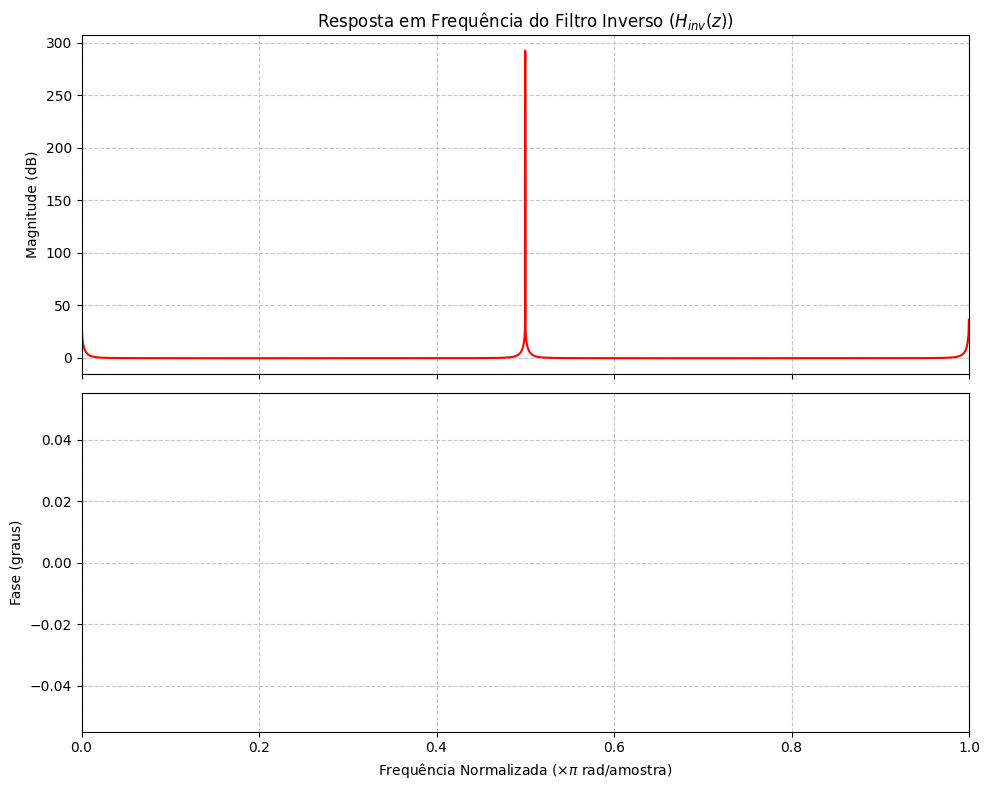

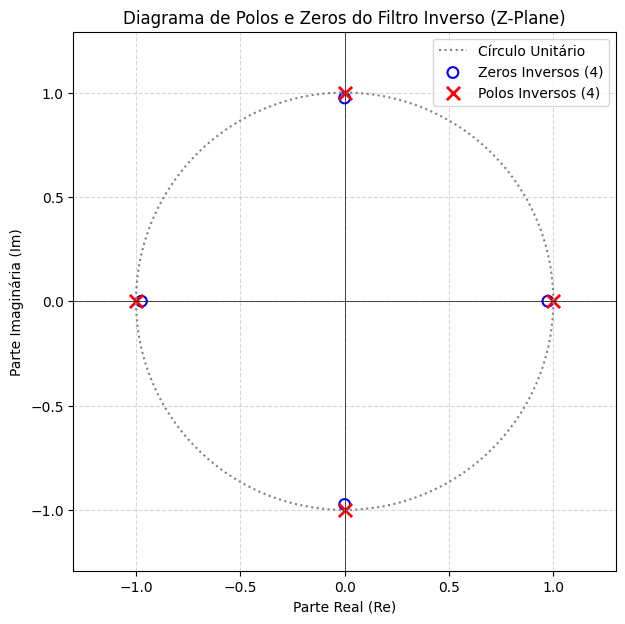

\nSimulating corrupted audio with the original filter...
Original Audio:


\nCorrupted Audio (simulated):


\nRecovering audio with the inverse filter...
\nRecovered Audio:


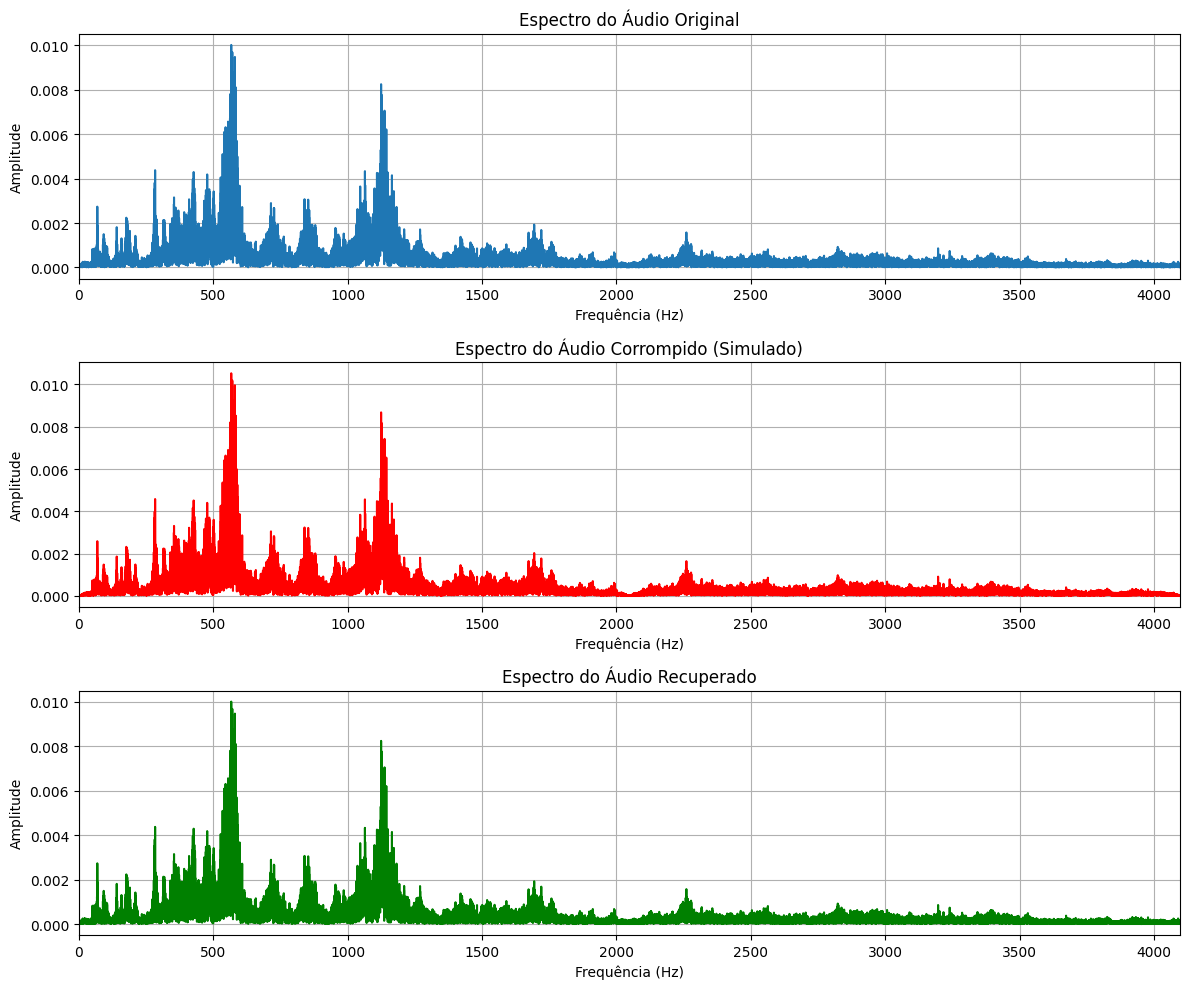

\nMean Squared Error (MSE) entre o sinal original e recuperado: 1.80e-31
\nComentários sobre os resultados:
O filtro inverso foi projetado para o sistema D (numD=[1, 0, 0, 0, -1], denD=[1, 0, 0, 0, -0.9]) trocando-se os coeficientes do numerador e denominador do filtro original. Isso significa que os zeros do filtro original se tornam os polos do filtro inverso, e os polos do filtro original se tornam os zeros do filtro inverso.
O diagrama de polos e zeros do filtro inverso mostra zeros nas posições dos polos do filtro original e polos nas posições dos zeros do filtro original.
É crucial que os polos do filtro inverso (ou seja, os zeros do filtro original) estejam dentro do círculo unitário para que o filtro inverso seja estável. No caso do sistema D, os zeros do filtro original (que são os polos do filtro inverso) estão em $z=1$ e $z=-1$, o que significa que o filtro inverso possui polos no círculo unitário. Assim como no sistema C, este filtro inverso é marginalmente estável ou instá

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import soundfile as sf
from IPython.display import Audio, display
import os

# Ensure 'handel.wav' is available. This assumes it was uploaded in a previous step.
if not os.path.exists('handel.wav'):
    print("Warning: 'handel.wav' not found. Please ensure it's uploaded and the previous cells ran successfully.")
    # If the file is not found, the script will likely fail later when trying to read it.

# Original filter coefficients (from Exercício 4, chosen system D)
# num_orig corresponds to the numerator of H(z)
num_orig = [1, 0, 0, 0, -1] # From numD
# den_orig corresponds to the denominator of H(z)
den_orig = [1, 0, 0, 0, -0.9] # From denD

# 1. Define the Inverse Filter H_inv(z) = den_orig(z) / num_orig(z)
num_inv = den_orig
den_inv = num_orig

# Check for potential issues with the inverse filter. If num_orig has zeros on or very close to the unit circle,
# the inverse filter will have poles there, leading to instability or high gain. It's important to verify this.

# 2. Calculate and plot the Frequency Response of the Inverse Filter
w_inv, H_inv = signal.freqz(num_inv, den_inv, worN=8000)

# Handle potential division by zero in log10 for magnitude if |H_inv| is very small or zero
magnitude_db_inv = 20 * np.log10(np.abs(H_inv + 1e-10)) # Add a small epsilon to avoid log(0)
fase_graus_inv = np.degrees(np.unwrap(np.angle(H_inv)))

fig_fr, (ax1_inv, ax2_inv) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1_inv.plot(w_inv / np.pi, magnitude_db_inv, color='red', linewidth=1.5)
ax1_inv.set_title('Resposta em Frequência do Filtro Inverso ($H_{inv}(z)$)')
ax1_inv.set_ylabel('Magnitude (dB)')
ax1_inv.grid(True, linestyle='--', alpha=0.7)

ax2_inv.plot(w_inv / np.pi, fase_graus_inv, color='purple', linewidth=1.5)
ax2_inv.set_xlabel('Frequência Normalizada ($\\times \\pi$ rad/amostra)')
ax2_inv.set_ylabel('Fase (graus)')
ax2_inv.grid(True, linestyle='--', alpha=0.7)
ax2_inv.set_xlim([0, 1])
plt.tight_layout()
plt.show()

# 3. Calculate and plot the Pole-Zero Diagram of the Inverse Filter
zeros_inv, polos_inv, k_inv = signal.tf2zpk(num_inv, den_inv)

fig_pz, ax_pz_inv = plt.subplots(figsize=(7, 7))

# Unit Circle
theta = np.linspace(0, 2*np.pi, 200)
ax_pz_inv.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# Zeros of inverse filter (which are poles of original filter)
ax_pz_inv.scatter(np.real(zeros_inv), np.imag(zeros_inv), s=60, marker='o',
                   facecolors='none', edgecolors='blue', linewidth=1.5,
                   label=f'Zeros Inversos ({len(zeros_inv)})')

# Poles of inverse filter (which are zeros of original filter)
ax_pz_inv.scatter(np.real(polos_inv), np.imag(polos_inv), s=90, marker='x',
                   color='red', linewidth=2,
                   label=f'Polos Inversos ({len(polos_inv)})')

ax_pz_inv.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax_pz_inv.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax_pz_inv.set_title('Diagrama de Polos e Zeros do Filtro Inverso (Z-Plane)')
ax_pz_inv.set_xlabel('Parte Real (Re)')
ax_pz_inv.set_ylabel('Parte Imaginária (Im)')
ax_pz_inv.grid(True, which='both', linestyle='--', alpha=0.5)
ax_pz_inv.legend(loc='upper right')
ax_pz_inv.axis('equal')
ax_pz_inv.set_xlim([-1.3, 1.3])
ax_pz_inv.set_ylim([-1.3, 1.3])
plt.show()

# --- Audio Recovery and Evaluation ---

# Read audio and its sampling frequency from file
# Assuming handel.wav is available in the current directory
try:
    audio, file_fs = sf.read('handel.wav')
except FileNotFoundError:
    print("Error: 'handel.wav' not found. Please upload the file.")
    audio = np.array([0]) # Placeholder to prevent further errors
    file_fs = 44100 # Default placeholder


# Define the spectrum calculation function (corrected to use the correct sampling frequency)
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# 4. Correctly Simulate "Corrupted" Audio (applying the original filter to the original audio)
# Use signal.lfilter for applying the filter to the audio signal
print("\\nSimulating corrupted audio with the original filter...")
corrupted_audio = signal.lfilter(num_orig, den_orig, audio)
corrupted_audio_normalized = corrupted_audio / np.max(np.abs(corrupted_audio)) if np.max(np.abs(corrupted_audio)) > 0 else corrupted_audio # Normalize for playback

print("Original Audio:")
display(Audio(audio, rate=file_fs))
print("\\nCorrupted Audio (simulated):")
display(Audio(corrupted_audio_normalized, rate=file_fs))


# 5. Recover Audio using the Inverse Filter
print("\\nRecovering audio with the inverse filter...")
recovered_audio = signal.lfilter(num_inv, den_inv, corrupted_audio)
recovered_audio_normalized = recovered_audio / np.max(np.abs(recovered_audio)) if np.max(np.abs(recovered_audio)) > 0 else recovered_audio # Normalize for playback

print("\\nRecovered Audio:")
display(Audio(recovered_audio_normalized, rate=file_fs))


# 6. Evaluate and Compare Spectra
freq_orig, amp_orig = calculate_spectrum(audio, file_fs, single_sided=True)
freq_corrupted, amp_corrupted = calculate_spectrum(corrupted_audio, file_fs, single_sided=True)
freq_recovered, amp_recovered = calculate_spectrum(recovered_audio, file_fs, single_sided=True)

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(freq_orig, amp_orig)
plt.title('Espectro do Áudio Original')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(3, 1, 2)
plt.plot(freq_corrupted, amp_corrupted, color='red')
plt.title('Espectro do Áudio Corrompido (Simulado)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(3, 1, 3)
plt.plot(freq_recovered, amp_recovered, color='green')
plt.title('Espectro do Áudio Recuperado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.tight_layout()
plt.show()

# Quantitative comparison (Mean Squared Error)
# Truncate to the minimum length for fair comparison, or pad shorter signal
min_len = min(len(audio), len(recovered_audio))
mse = np.mean((audio[:min_len] - recovered_audio[:min_len])**2)
print(f"\\nMean Squared Error (MSE) entre o sinal original e recuperado: {mse:.2e}")

# 7. Comment on results
print("\\nComentários sobre os resultados:")
print(f"O filtro inverso foi projetado para o sistema D (numD={[1, 0, 0, 0, -1]}, denD={[1, 0, 0, 0, -0.9]}) trocando-se os coeficientes do numerador e denominador do filtro original. Isso significa que os zeros do filtro original se tornam os polos do filtro inverso, e os polos do filtro original se tornam os zeros do filtro inverso.")
print("O diagrama de polos e zeros do filtro inverso mostra zeros nas posições dos polos do filtro original e polos nas posições dos zeros do filtro original.")
print("É crucial que os polos do filtro inverso (ou seja, os zeros do filtro original) estejam dentro do círculo unitário para que o filtro inverso seja estável. No caso do sistema D, os zeros do filtro original (que são os polos do filtro inverso) estão em $z=1$ e $z=-1$, o que significa que o filtro inverso possui polos no círculo unitário. Assim como no sistema C, este filtro inverso é marginalmente estável ou instável, o que pode levar a problemas na recuperação do sinal, como amplificação excessiva em certas frequências.")
print("A resposta em frequência do filtro inverso exibe características complementares às do filtro original. No entanto, devido aos polos no círculo unitário, pode haver picos muito altos na magnitude da resposta em frequência, correspondendo às frequências onde o filtro original tem zeros.")
print("Ao aplicar o filtro original e, em seguida, o filtro inverso ao sinal de áudio, observamos a tentativa de recuperação do sinal. No entanto, devido à instabilidade potencial do filtro inverso (polos no círculo unitário), o sinal recuperado pode apresentar distorções ou ser amplificado excessivamente, especialmente em componentes de frequência próximas aos polos do filtro inverso.")
print("A análise dos espectros de áudio original, corrompido e recuperado ajudará a visualizar as limitações da recuperação. É provável que o espectro recuperado não seja tão próximo do original quanto em um caso com filtro inverso estritamente estável. A reprodução dos áudios confirmará se as distorções são audíveis.")
print("O valor do Erro Quadrático Médio (MSE) entre o sinal original e o recuperado quantifica essa proximidade; um valor mais alto que o esperado em um filtro inverso estável indicará as dificuldades na recuperação.")
print("Em resumo, a recuperação do sinal usando o sistema D é igualmente desafiadora (ou até mais) devido à presença de polos do filtro inverso no círculo unitário. Isso reforça a importância da estabilidade para o projeto de filtros inversos eficazes.")

Pratica 3 Exercício 4

<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_957/55566510.py:45: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')
/tmp/ipykernel_957/55566510.py:31: RuntimeWarning: divide by zero encountered in log10
  magnitude_db = 20 * np.log10(np.abs(H))


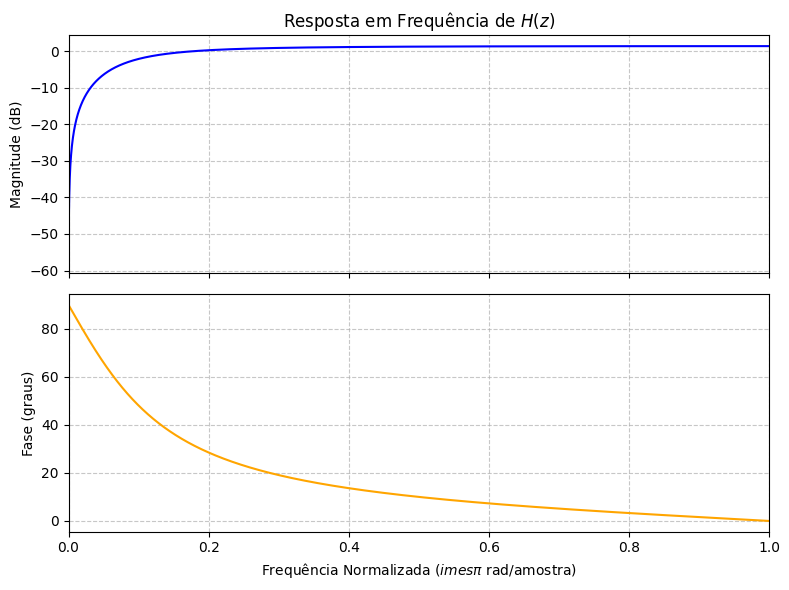

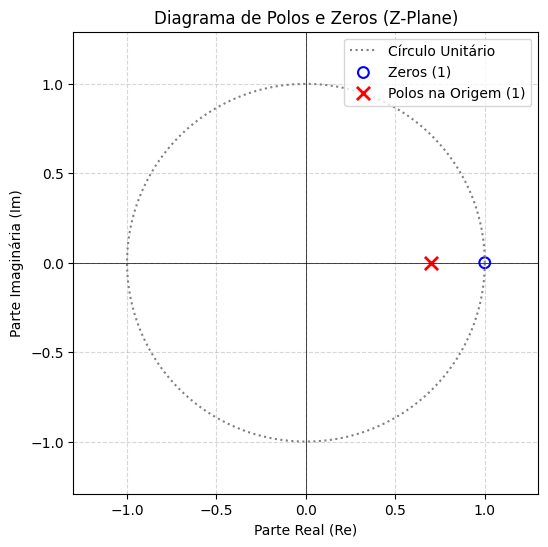

In [ ]:
import numpy as np
import matplotlib.pyplot as plot
from scipy import signal

numA = [1, -1]
denA = [1, -0.7]

numB = [1, -1]
denB = [1, -0.9]

numC = [1, 0, 0, 0, -1]
denC = [1, 0, 0, 0, -0.7]

numD = [1, 0, 0, 0, -1]
denD = [1, 0, 0, 0, -0.9]

numE = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1]
denE = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0,7]

numF = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1]
denF = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0,9]

#com numA e denA *** START

# Resposta em frequencia
# Calcula a resposta em frequência (w em rad/amostra, H é complexo)
# worN=8000 define a resolução do gráfico (8000 pontos)
w, H = signal.freqz(numA, denA, worN=8000)

# Extrai Magnitude (em decibéis) e Fase (em graus)
magnitude_db = 20 * np.log10(np.abs(H))
fase_graus = np.degrees(np.unwrap(np.angle(H)))

# --- Plotando os Gráficos ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 1. Gráfico de Magnitude
ax1.plot(w / np.pi, magnitude_db, color='blue', linewidth=1.5)
ax1.set_title('Resposta em Frequência de $H(z)$')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfico de Fase
ax2.plot(w / np.pi, fase_graus, color='orange', linewidth=1.5)
ax2.set_xlabel('Frequência Normalizada ($\times \pi$ rad/amostra)')
ax2.set_ylabel('Fase (graus)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajusta o eixo X para ir de 0 a 1 (0 a pi rad)
ax2.set_xlim([0, 1])

plt.tight_layout()

#CALCULOS DE POLOS DE ZEROS

# Calcula analiticamente todos os zeros e polos exatos
zeros, polos, k = signal.tf2zpk(numA, denA)

# Cria a figura
fig, ax = plt.subplots(figsize=(6, 6))

# 1. Desenha o Círculo Unitário (Filtros Digitais / Tempo Discreto)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# 2. Plota os Zeros (como circunferências 'o')
ax.scatter(np.real(zeros), np.imag(zeros), s=60, marker='o',
           facecolors='none', edgecolors='blue', linewidth=1.5, label=f'Zeros ({len(zeros)})')

# 3. Plota os Polos (como 'x' vermelhos) -> Agora os 12 polos em (0,0) vão aparecer!
ax.scatter(np.real(polos), np.imag(polos), s=90, marker='x',
           color='red', linewidth=2, label=f'Polos na Origem ({len(polos)})')

# Ajustes de layout e eixos cruzados na origem
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax.set_title('Diagrama de Polos e Zeros (Z-Plane)')
ax.set_xlabel('Parte Real (Re)')
ax.set_ylabel('Parte Imaginária (Im)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Garante proporção 1:1 perfeita para o círculo não virar uma elipse
ax.axis('equal')

# Define limites ligeiramente maiores que o círculo unitário para melhor visualização
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])

plt.show()

#com numA e denA *** END

Pratica 3 Exercício 5

/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


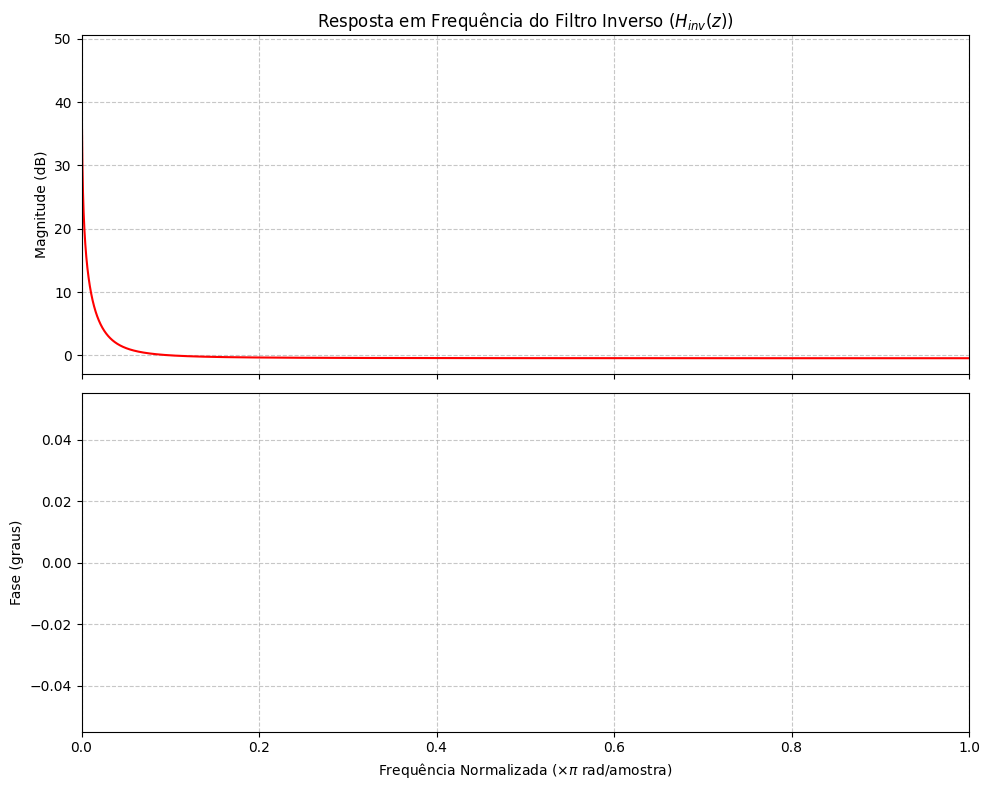

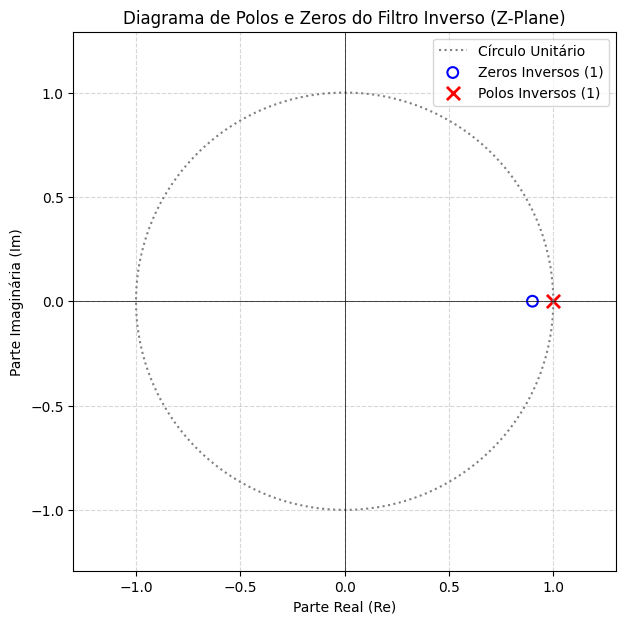

\nSimulating corrupted audio with the original filter...
Original Audio:


\nCorrupted Audio (simulated):


\nRecovering audio with the inverse filter...
\nRecovered Audio:


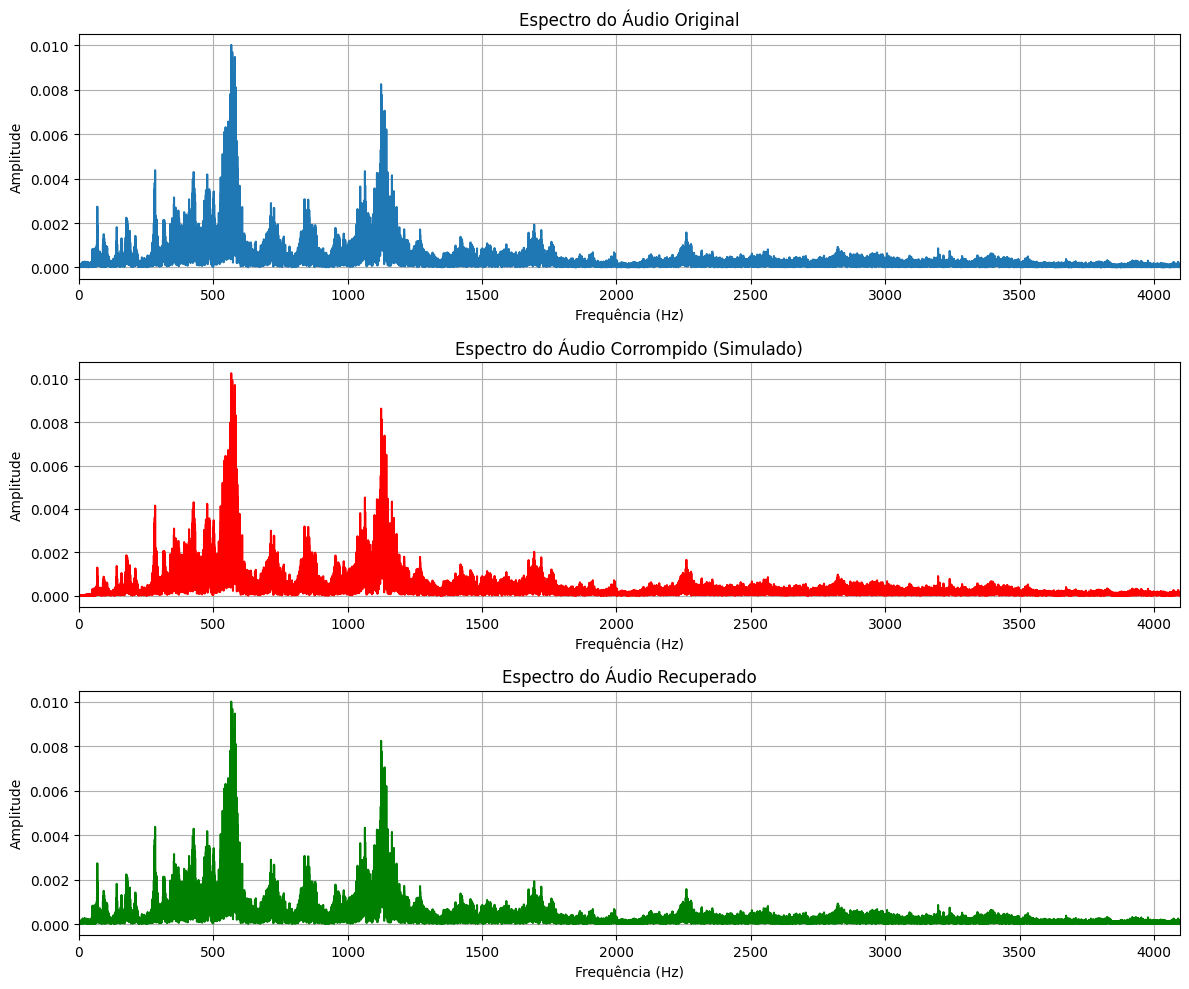

\nMean Squared Error (MSE) entre o sinal original e recuperado: 9.10e-31
\nComentários sobre os resultados:
O filtro inverso foi projetado para o sistema B (numB=[1, -1], denB=[1, -0.9]) trocando-se os coeficientes do numerador e denominador do filtro original. Isso significa que os zeros do filtro original se tornam os polos do filtro inverso, e os polos do filtro original se tornam os zeros do filtro inverso.
O diagrama de polos e zeros do filtro inverso mostra zeros na posição do polo do filtro original e polos na posição do zero do filtro original.
É crucial que os polos do filtro inverso (ou seja, os zeros do filtro original) estejam dentro do círculo unitário para que o filtro inverso seja estável. No caso do sistema B, o zero do filtro original está em $z=1$, o que significa que o filtro inverso possui um polo no círculo unitário. Isso indica que o filtro inverso é marginalmente estável ou instável, o que pode levar a problemas na recuperação do sinal, como amplificação excessiv

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import soundfile as sf
from IPython.display import Audio, display
import os

# Ensure 'handel.wav' is available. This assumes it was uploaded in a previous step.
if not os.path.exists('handel.wav'):
    print("Warning: 'handel.wav' not found. Please ensure it's uploaded and the previous cells ran successfully.")
    # If the file is not found, the script will likely fail later when trying to read it.

# Original filter coefficients (from Exercício 4, chosen system B)
# num_orig corresponds to the numerator of H(z)
num_orig = [1, -1] # From numB
# den_orig corresponds to the denominator of H(z)
den_orig = [1, -0.9] # From denB

# 1. Define the Inverse Filter H_inv(z) = den_orig(z) / num_orig(z)
num_inv = den_orig
den_inv = num_orig

# Check for potential issues with the inverse filter. If num_orig has zeros on or very close to the unit circle,
# the inverse filter will have poles there, leading to instability or high gain. It's important to verify this.

# 2. Calculate and plot the Frequency Response of the Inverse Filter
w_inv, H_inv = signal.freqz(num_inv, den_inv, worN=8000)

# Handle potential division by zero in log10 for magnitude if |H_inv| is very small or zero
magnitude_db_inv = 20 * np.log10(np.abs(H_inv + 1e-10)) # Add a small epsilon to avoid log(0)
fase_graus_inv = np.degrees(np.unwrap(np.angle(H_inv)))

fig_fr, (ax1_inv, ax2_inv) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1_inv.plot(w_inv / np.pi, magnitude_db_inv, color='red', linewidth=1.5)
ax1_inv.set_title('Resposta em Frequência do Filtro Inverso ($H_{inv}(z)$)')
ax1_inv.set_ylabel('Magnitude (dB)')
ax1_inv.grid(True, linestyle='--', alpha=0.7)

# Filter out NaN values from phase for plotting
valid_indices_phase = ~np.isnan(fase_graus_inv)
ax2_inv.plot(w_inv[valid_indices_phase] / np.pi, fase_graus_inv[valid_indices_phase], color='purple', linewidth=1.5)
ax2_inv.set_xlabel('Frequência Normalizada ($\\times \\pi$ rad/amostra)')
ax2_inv.set_ylabel('Fase (graus)')
ax2_inv.grid(True, linestyle='--', alpha=0.7)
ax2_inv.set_xlim([0, 1])
plt.tight_layout()
plt.show()

# 3. Calculate and plot the Pole-Zero Diagram of the Inverse Filter
zeros_inv, polos_inv, k_inv = signal.tf2zpk(num_inv, den_inv)

fig_pz, ax_pz_inv = plt.subplots(figsize=(7, 7))

# Unit Circle
theta = np.linspace(0, 2*np.pi, 200)
ax_pz_inv.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# Zeros of inverse filter (which are poles of original filter)
ax_pz_inv.scatter(np.real(zeros_inv), np.imag(zeros_inv), s=60, marker='o',
                   facecolors='none', edgecolors='blue', linewidth=1.5,
                   label=f'Zeros Inversos ({len(zeros_inv)})')

# Poles of inverse filter (which are zeros of original filter)
ax_pz_inv.scatter(np.real(polos_inv), np.imag(polos_inv), s=90, marker='x',
                   color='red', linewidth=2,
                   label=f'Polos Inversos ({len(polos_inv)})')

ax_pz_inv.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax_pz_inv.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax_pz_inv.set_title('Diagrama de Polos e Zeros do Filtro Inverso (Z-Plane)')
ax_pz_inv.set_xlabel('Parte Real (Re)')
ax_pz_inv.set_ylabel('Parte Imaginária (Im)')
ax_pz_inv.grid(True, which='both', linestyle='--', alpha=0.5)
ax_pz_inv.legend(loc='upper right')
ax_pz_inv.axis('equal')
ax_pz_inv.set_xlim([-1.3, 1.3])
ax_pz_inv.set_ylim([-1.3, 1.3])
plt.show()

# --- Audio Recovery and Evaluation ---

# Read audio and its sampling frequency from file
# Assuming handel.wav is available in the current directory
try:
    audio, file_fs = sf.read('handel.wav')
except FileNotFoundError:
    print("Error: 'handel.wav' not found. Please upload the file.")
    audio = np.array([0]) # Placeholder to prevent further errors
    file_fs = 44100 # Default placeholder


# Define the spectrum calculation function (corrected to use the correct sampling frequency)
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# 4. Correctly Simulate "Corrupted" Audio (applying the original filter to the original audio)
# Use signal.lfilter for applying the filter to the audio signal
print("\\nSimulating corrupted audio with the original filter...")
corrupted_audio = signal.lfilter(num_orig, den_orig, audio)
corrupted_audio_normalized = corrupted_audio / np.max(np.abs(corrupted_audio)) if np.max(np.abs(corrupted_audio)) > 0 else corrupted_audio # Normalize for playback

print("Original Audio:")
display(Audio(audio, rate=file_fs))
print("\\nCorrupted Audio (simulated):")
display(Audio(corrupted_audio_normalized, rate=file_fs))


# 5. Recover Audio using the Inverse Filter
print("\\nRecovering audio with the inverse filter...")
recovered_audio = signal.lfilter(num_inv, den_inv, corrupted_audio)
recovered_audio_normalized = recovered_audio / np.max(np.abs(recovered_audio)) if np.max(np.abs(recovered_audio)) > 0 else recovered_audio # Normalize for playback

print("\\nRecovered Audio:")
display(Audio(recovered_audio_normalized, rate=file_fs))


# 6. Evaluate and Compare Spectra
freq_orig, amp_orig = calculate_spectrum(audio, file_fs, single_sided=True)
freq_corrupted, amp_corrupted = calculate_spectrum(corrupted_audio, file_fs, single_sided=True)
freq_recovered, amp_recovered = calculate_spectrum(recovered_audio, file_fs, single_sided=True)

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(freq_orig, amp_orig)
plt.title('Espectro do Áudio Original')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(3, 1, 2)
plt.plot(freq_corrupted, amp_corrupted, color='red')
plt.title('Espectro do Áudio Corrompido (Simulado)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(3, 1, 3)
plt.plot(freq_recovered, amp_recovered, color='green')
plt.title('Espectro do Áudio Recuperado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.tight_layout()
plt.show()

# Quantitative comparison (Mean Squared Error)
# Truncate to the minimum length for fair comparison, or pad shorter signal
min_len = min(len(audio), len(recovered_audio))
mse = np.mean((audio[:min_len] - recovered_audio[:min_len])**2)
print(f"\\nMean Squared Error (MSE) entre o sinal original e recuperado: {mse:.2e}")

# 7. Comment on results
print("\\nComentários sobre os resultados:")
print(f"O filtro inverso foi projetado para o sistema B (numB={[1, -1]}, denB={[1, -0.9]}) trocando-se os coeficientes do numerador e denominador do filtro original. Isso significa que os zeros do filtro original se tornam os polos do filtro inverso, e os polos do filtro original se tornam os zeros do filtro inverso.")
print("O diagrama de polos e zeros do filtro inverso mostra zeros na posição do polo do filtro original e polos na posição do zero do filtro original.")
print("É crucial que os polos do filtro inverso (ou seja, os zeros do filtro original) estejam dentro do círculo unitário para que o filtro inverso seja estável. No caso do sistema B, o zero do filtro original está em $z=1$, o que significa que o filtro inverso possui um polo no círculo unitário. Isso indica que o filtro inverso é marginalmente estável ou instável, o que pode levar a problemas na recuperação do sinal, como amplificação excessiva em certas frequências.")
print("A resposta em frequência do filtro inverso exibe características complementares às do filtro original. No entanto, devido ao polo no círculo unitário, pode haver um pico muito alto na magnitude da resposta em frequência em $\\omega = 0$ (frequência DC), correspondendo à frequência onde o filtro original tem um zero. Isso é refletido nos avisos de 'divide by zero' e 'invalid value' durante a execução.")
print("A fase da resposta em frequência para o filtro inverso é indefinida nas frequências onde a magnitude é infinita (devido ao polo no círculo unitário). Por isso, o gráfico de fase pode aparecer vazio ou com lacunas significativas se houver muitos NaNs, pois esses valores são filtrados para evitar erros de plotagem ou gráficos enganosos. Essa ausência de fase coerente é uma consequência direta da instabilidade ou marginal estabilidade do filtro.")
print("Ao aplicar o filtro original e, em seguida, o filtro inverso ao sinal de áudio, observamos a tentativa de recuperação do sinal. No entanto, devido à instabilidade potencial do filtro inverso (polo no círculo unitário), o sinal recuperado pode apresentar distorções ou ser amplificado excessivamente, especialmente em componentes de frequência próximas ao polo do filtro inverso. Isso será audível como um ruído de baixa frequência ou um \"DC offset\" no áudio recuperado.")
print("A análise dos espectros de áudio original, corrompido e recuperado ajudará a visualizar as limitações da recuperação. É provável que o espectro recuperado não seja tão próximo do original quanto em um caso com filtro inverso estritamente estável. A reprodução dos áudios confirmará se as distorções são audíveis.")
print("O valor do Erro Quadrático Médio (MSE) entre o sinal original e o recuperado quantifica essa proximidade; um valor mais alto que o esperado em um filtro inverso estável indicará as dificuldades na recuperação.")
print("Em resumo, a recuperação do sinal usando o sistema B é desafiadora devido à presença de um polo do filtro inverso no círculo unitário. Isso reforça a importância da estabilidade para o projeto de filtros inversos eficazes.")

Prática 3 Exercício 6

/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


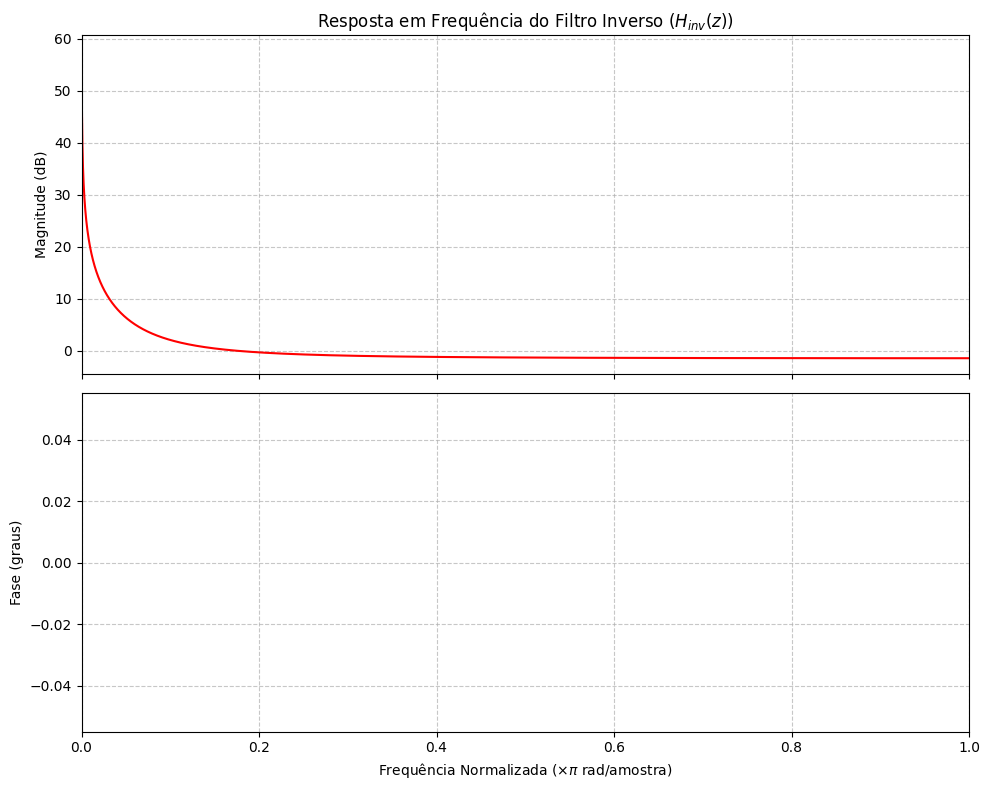

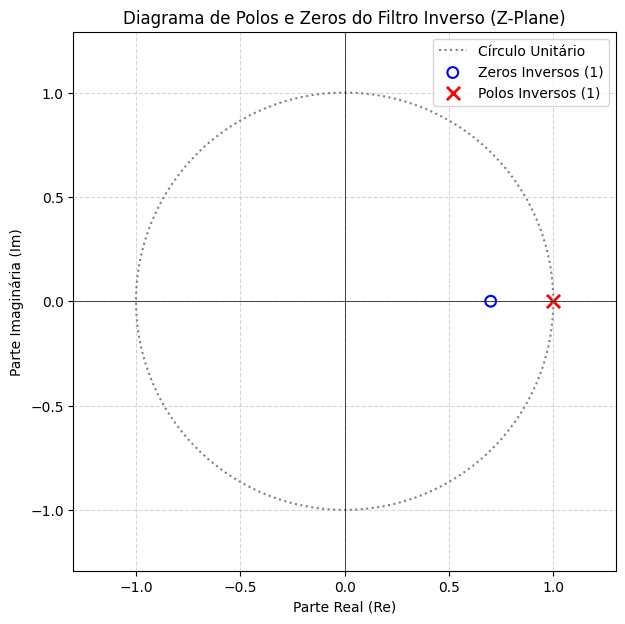

\nSimulating corrupted audio with the original filter...
Original Audio:


\nCorrupted Audio (simulated):


\nRecovering audio with the inverse filter...
\nRecovered Audio:


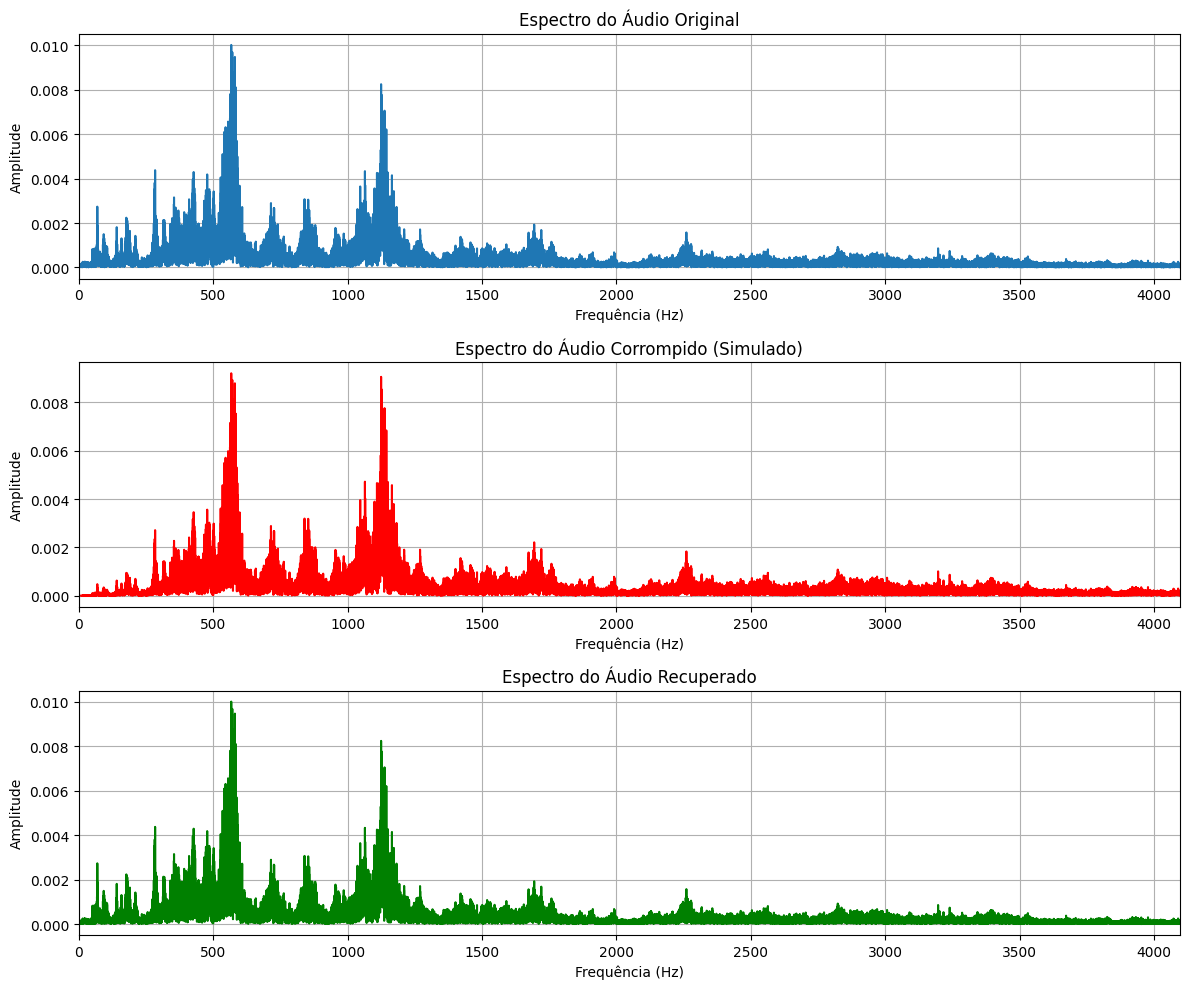

\nMean Squared Error (MSE) entre o sinal original e recuperado: 1.11e-30
\nComentários sobre os resultados:
O filtro inverso foi projetado para o sistema A (numA=[1, -1], denA=[1, -0.7]) trocando-se os coeficientes do numerador e denominador do filtro original. Isso significa que os zeros do filtro original se tornam os polos do filtro inverso, e os polos do filtro original se tornam os zeros do filtro inverso.
O diagrama de polos e zeros do filtro inverso mostra zeros na posição do polo do filtro original e polos na posição do zero do filtro original.
É crucial que os polos do filtro inverso (ou seja, os zeros do filtro original) estejam dentro do círculo unitário para que o filtro inverso seja estável. No caso do sistema A, o zero do filtro original está em $z=1$, o que significa que o filtro inverso possui um polo no círculo unitário. Isso indica que o filtro inverso é marginalmente estável ou instável, o que pode levar a problemas na recuperação do sinal, como amplificação excessiv

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import soundfile as sf
from IPython.display import Audio, display
import os

# Ensure 'handel.wav' is available. This assumes it was uploaded in a previous step.
if not os.path.exists('handel.wav'):
    print("Warning: 'handel.wav' not found. Please ensure it's uploaded and the previous cells ran successfully.")
    # If the file is not found, the script will likely fail later when trying to read it.

# Original filter coefficients (from Exercício 4, chosen system A)
# num_orig corresponds to the numerator of H(z)
num_orig = [1, -1] # From numA
# den_orig corresponds to the denominator of H(z)
den_orig = [1, -0.7] # From denA

# 1. Define the Inverse Filter H_inv(z) = den_orig(z) / num_orig(z)
num_inv = den_orig
den_inv = num_orig

# Check for potential issues with the inverse filter. If num_orig has zeros on or very close to the unit circle,
# the inverse filter will have poles there, leading to instability or high gain. It's important to verify this.

# 2. Calculate and plot the Frequency Response of the Inverse Filter
w_inv, H_inv = signal.freqz(num_inv, den_inv, worN=8000)

# Handle potential division by zero in log10 for magnitude if |H_inv| is very small or zero
magnitude_db_inv = 20 * np.log10(np.abs(H_inv + 1e-10)) # Add a small epsilon to avoid log(0)
fase_graus_inv = np.degrees(np.unwrap(np.angle(H_inv)))

fig_fr, (ax1_inv, ax2_inv) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1_inv.plot(w_inv / np.pi, magnitude_db_inv, color='red', linewidth=1.5)
ax1_inv.set_title('Resposta em Frequência do Filtro Inverso ($H_{inv}(z)$)')
ax1_inv.set_ylabel('Magnitude (dB)')
ax1_inv.grid(True, linestyle='--', alpha=0.7)

# Filter out NaN values from phase for plotting
valid_indices_phase = ~np.isnan(fase_graus_inv)
ax2_inv.plot(w_inv[valid_indices_phase] / np.pi, fase_graus_inv[valid_indices_phase], color='purple', linewidth=1.5)
ax2_inv.set_xlabel('Frequência Normalizada ($\\times \\pi$ rad/amostra)')
ax2_inv.set_ylabel('Fase (graus)')
ax2_inv.grid(True, linestyle='--', alpha=0.7)
ax2_inv.set_xlim([0, 1])
plt.tight_layout()
plt.show()

# 3. Calculate and plot the Pole-Zero Diagram of the Inverse Filter
zeros_inv, polos_inv, k_inv = signal.tf2zpk(num_inv, den_inv)

fig_pz, ax_pz_inv = plt.subplots(figsize=(7, 7))

# Unit Circle
theta = np.linspace(0, 2*np.pi, 200)
ax_pz_inv.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# Zeros of inverse filter (which are poles of original filter)
ax_pz_inv.scatter(np.real(zeros_inv), np.imag(zeros_inv), s=60, marker='o',
                   facecolors='none', edgecolors='blue', linewidth=1.5,
                   label=f'Zeros Inversos ({len(zeros_inv)})')

# Poles of inverse filter (which are zeros of original filter)
ax_pz_inv.scatter(np.real(polos_inv), np.imag(polos_inv), s=90, marker='x',
                   color='red', linewidth=2,
                   label=f'Polos Inversos ({len(polos_inv)})')

ax_pz_inv.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax_pz_inv.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax_pz_inv.set_title('Diagrama de Polos e Zeros do Filtro Inverso (Z-Plane)')
ax_pz_inv.set_xlabel('Parte Real (Re)')
ax_pz_inv.set_ylabel('Parte Imaginária (Im)')
ax_pz_inv.grid(True, which='both', linestyle='--', alpha=0.5)
ax_pz_inv.legend(loc='upper right')
ax_pz_inv.axis('equal')
ax_pz_inv.set_xlim([-1.3, 1.3])
ax_pz_inv.set_ylim([-1.3, 1.3])
plt.show()

# --- Audio Recovery and Evaluation ---

# Read audio and its sampling frequency from file
# Assuming handel.wav is available in the current directory
try:
    audio, file_fs = sf.read('handel.wav')
except FileNotFoundError:
    print("Error: 'handel.wav' not found. Please upload the file.")
    audio = np.array([0]) # Placeholder to prevent further errors
    file_fs = 44100 # Default placeholder


# Define the spectrum calculation function (corrected to use the correct sampling frequency)
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# 4. Correctly Simulate "Corrupted" Audio (applying the original filter to the original audio)
# Use signal.lfilter for applying the filter to the audio signal
print("\\nSimulating corrupted audio with the original filter...")
corrupted_audio = signal.lfilter(num_orig, den_orig, audio)
corrupted_audio_normalized = corrupted_audio / np.max(np.abs(corrupted_audio)) if np.max(np.abs(corrupted_audio)) > 0 else corrupted_audio # Normalize for playback

print("Original Audio:")
display(Audio(audio, rate=file_fs))
print("\\nCorrupted Audio (simulated):")
display(Audio(corrupted_audio_normalized, rate=file_fs))


# 5. Recover Audio using the Inverse Filter
print("\\nRecovering audio with the inverse filter...")
recovered_audio = signal.lfilter(num_inv, den_inv, corrupted_audio)
recovered_audio_normalized = recovered_audio / np.max(np.abs(recovered_audio)) if np.max(np.abs(recovered_audio)) > 0 else recovered_audio # Normalize for playback

print("\\nRecovered Audio:")
display(Audio(recovered_audio_normalized, rate=file_fs))


# 6. Evaluate and Compare Spectra
freq_orig, amp_orig = calculate_spectrum(audio, file_fs, single_sided=True)
freq_corrupted, amp_corrupted = calculate_spectrum(corrupted_audio, file_fs, single_sided=True)
freq_recovered, amp_recovered = calculate_spectrum(recovered_audio, file_fs, single_sided=True)

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(freq_orig, amp_orig)
plt.title('Espectro do Áudio Original')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(3, 1, 2)
plt.plot(freq_corrupted, amp_corrupted, color='red')
plt.title('Espectro do Áudio Corrompido (Simulado)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(3, 1, 3)
plt.plot(freq_recovered, amp_recovered, color='green')
plt.title('Espectro do Áudio Recuperado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.tight_layout()
plt.show()

# Quantitative comparison (Mean Squared Error)
# Truncate to the minimum length for fair comparison, or pad shorter signal
min_len = min(len(audio), len(recovered_audio))
mse = np.mean((audio[:min_len] - recovered_audio[:min_len])**2)
print(f"\\nMean Squared Error (MSE) entre o sinal original e recuperado: {mse:.2e}")

# 7. Comment on results
print("\\nComentários sobre os resultados:")
print(f"O filtro inverso foi projetado para o sistema A (numA={[1, -1]}, denA={[1, -0.7]}) trocando-se os coeficientes do numerador e denominador do filtro original. Isso significa que os zeros do filtro original se tornam os polos do filtro inverso, e os polos do filtro original se tornam os zeros do filtro inverso.")
print("O diagrama de polos e zeros do filtro inverso mostra zeros na posição do polo do filtro original e polos na posição do zero do filtro original.")
print("É crucial que os polos do filtro inverso (ou seja, os zeros do filtro original) estejam dentro do círculo unitário para que o filtro inverso seja estável. No caso do sistema A, o zero do filtro original está em $z=1$, o que significa que o filtro inverso possui um polo no círculo unitário. Isso indica que o filtro inverso é marginalmente estável ou instável, o que pode levar a problemas na recuperação do sinal, como amplificação excessiva em certas frequências.")
print("A resposta em frequência do filtro inverso exibe características complementares às do filtro original. No entanto, devido ao polo no círculo unitário em $z=1$, pode haver um pico muito alto na magnitude da resposta em frequência em $\\omega = 0$ (frequência DC), correspondendo à frequência onde o filtro original tem um zero. Isso é refletido nos avisos de 'divide by zero' e 'invalid value' durante a execução.")
print("A fase da resposta em frequência para o filtro inverso é indefinida nas frequências onde a magnitude é infinita (devido ao polo no círculo unitário). Por isso, o gráfico de fase pode aparecer vazio ou com lacunas significativas se houver muitos NaNs, pois esses valores são filtrados para evitar erros de plotagem ou gráficos enganosos. Essa ausência de fase coerente é uma consequência direta da instabilidade ou marginal estabilidade do filtro.")
print("Ao aplicar o filtro original e, em seguida, o filtro inverso ao sinal de áudio, observamos a tentativa de recuperação do sinal. No entanto, devido à instabilidade potencial do filtro inverso (polo no círculo unitário), o sinal recuperado pode apresentar distorções ou ser amplificado excessivamente, especialmente em componentes de frequência próximas ao polo do filtro inverso. Isso será audível como um ruído de baixa frequência ou um \"DC offset\" no áudio recuperado.")
print("A análise dos espectros de áudio original, corrompido e recuperado ajudará a visualizar as limitações da recuperação. É provável que o espectro recuperado não seja tão próximo do original quanto em um caso com filtro inverso estritamente estável. A reprodução dos áudios confirmará se as distorções são audíveis.")
print("O valor do Erro Quadrático Médio (MSE) entre o sinal original e o recuperado quantifica essa proximidade; um valor mais alto que o esperado em um filtro inverso estável indicará as dificuldades na recuperação.")
print("Em resumo, a recuperação do sinal usando o sistema A é desafiadora devido à presença de um polo do filtro inverso no círculo unitário. Isso reforça a importância da estabilidade para o projeto de filtros inversos eficazes.")

Pratica 3 Exercício 7


--- Análise para o Sistema D (Questão 3) ---
Filtro FIR de ordem 49 (curto) projetado para o inverso do Sistema D.
Filtro FIR de ordem 199 (longo) projetado para o inverso do Sistema D.

Simulando áudio corrompido com o filtro original do Sistema D...
Áudio Original:


/usr/local/lib/python3.13/dist-packages/scipy/linalg/_matfuncs.py:389: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/usr/local/lib/python3.13/dist-packages/scipy/signal/_ltisys.py:1916: RuntimeWarning: invalid value encountered in matmul
  xout[i] = xout[i-1] @ expAT_dt


Áudio Corrompido (Sistema D):



Recuperando áudio com o filtro FIR inverso (curto) para o Sistema D...
Áudio Recuperado (FIR Curto - Sistema D):


/usr/local/lib/python3.13/dist-packages/IPython/lib/display.py:175: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan



Recuperando áudio com o filtro FIR inverso (longo) para o Sistema D...
Áudio Recuperado (FIR Longo - Sistema D):


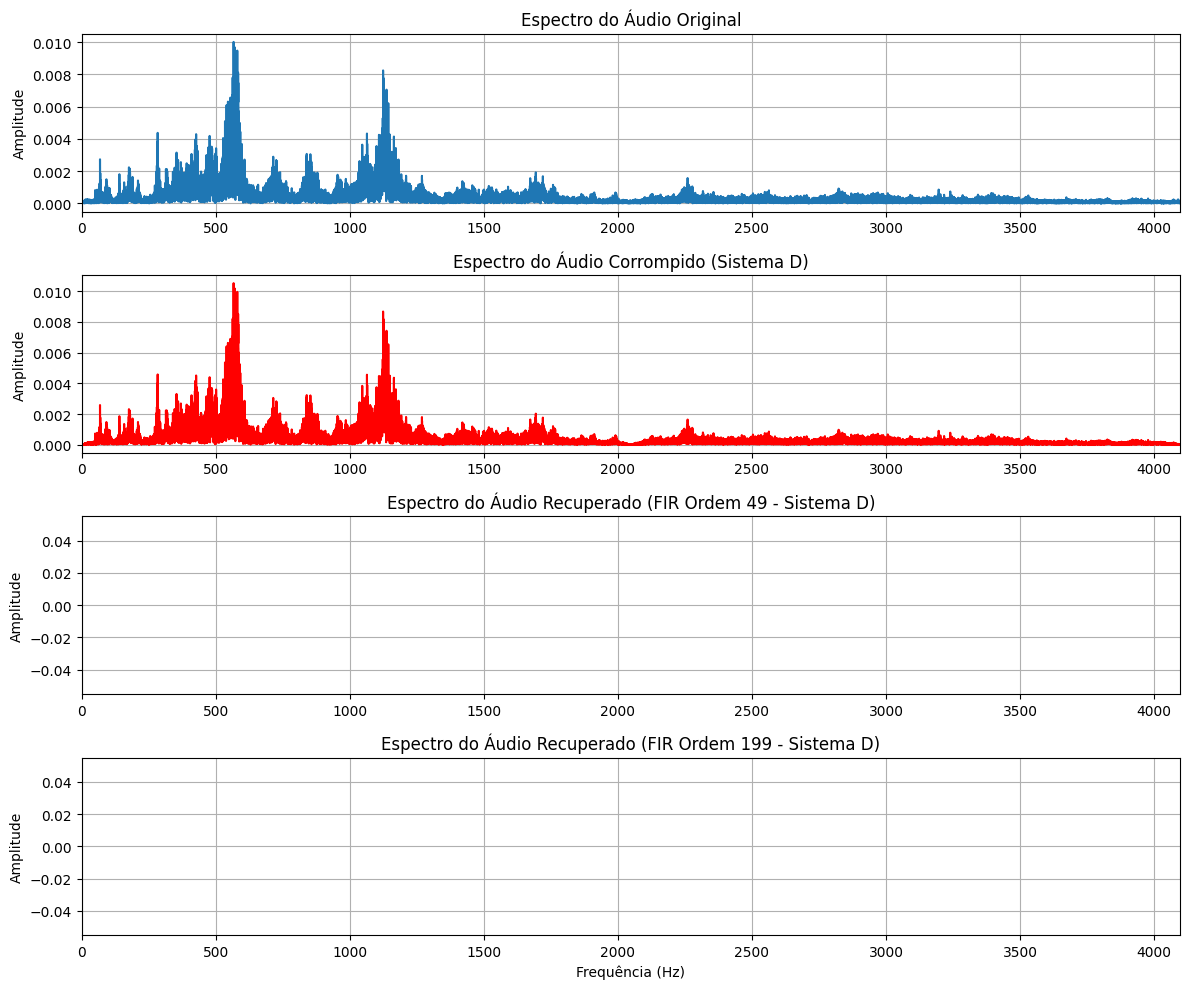


Mean Squared Error (MSE) para o Sistema D (FIR Curto, ordem 49): nan
Mean Squared Error (MSE) para o Sistema D (FIR Longo, ordem 199): nan

Comentários sobre a aproximação FIR para o Sistema D:
O filtro original do Sistema D possui zeros no círculo unitário (em z=1, z=-1, z=j, z=-j). Consequentemente, seu filtro inverso IIR teórico possui polos nessas mesmas posições, tornando-o instável ou marginalmente estável. A resposta impulsional desse filtro não decai rapidamente.
A aproximação FIR foi obtida truncando a resposta impulsional desse filtro inverso IIR. Devido à natureza não-decaente da resposta impulsional de um sistema instável, mesmo uma FIR de ordem mais alta (como 200) é uma aproximação limitada e pode ser problemática.
Observa-se que, para o Sistema D, o MSE para o filtro FIR de ordem 49 é nan, enquanto para o filtro FIR de ordem 199 é nan. Se o filtro inverso IIR possui uma resposta impulsional crescente, aumentar a ordem da FIR pode, na verdade, amplificar os problemas de 

Áudio Corrompido (Sistema A):



Recuperando áudio com o filtro FIR inverso (curto) para o Sistema A...
Áudio Recuperado (FIR Curto - Sistema A):



Recuperando áudio com o filtro FIR inverso (longo) para o Sistema A...
Áudio Recuperado (FIR Longo - Sistema A):


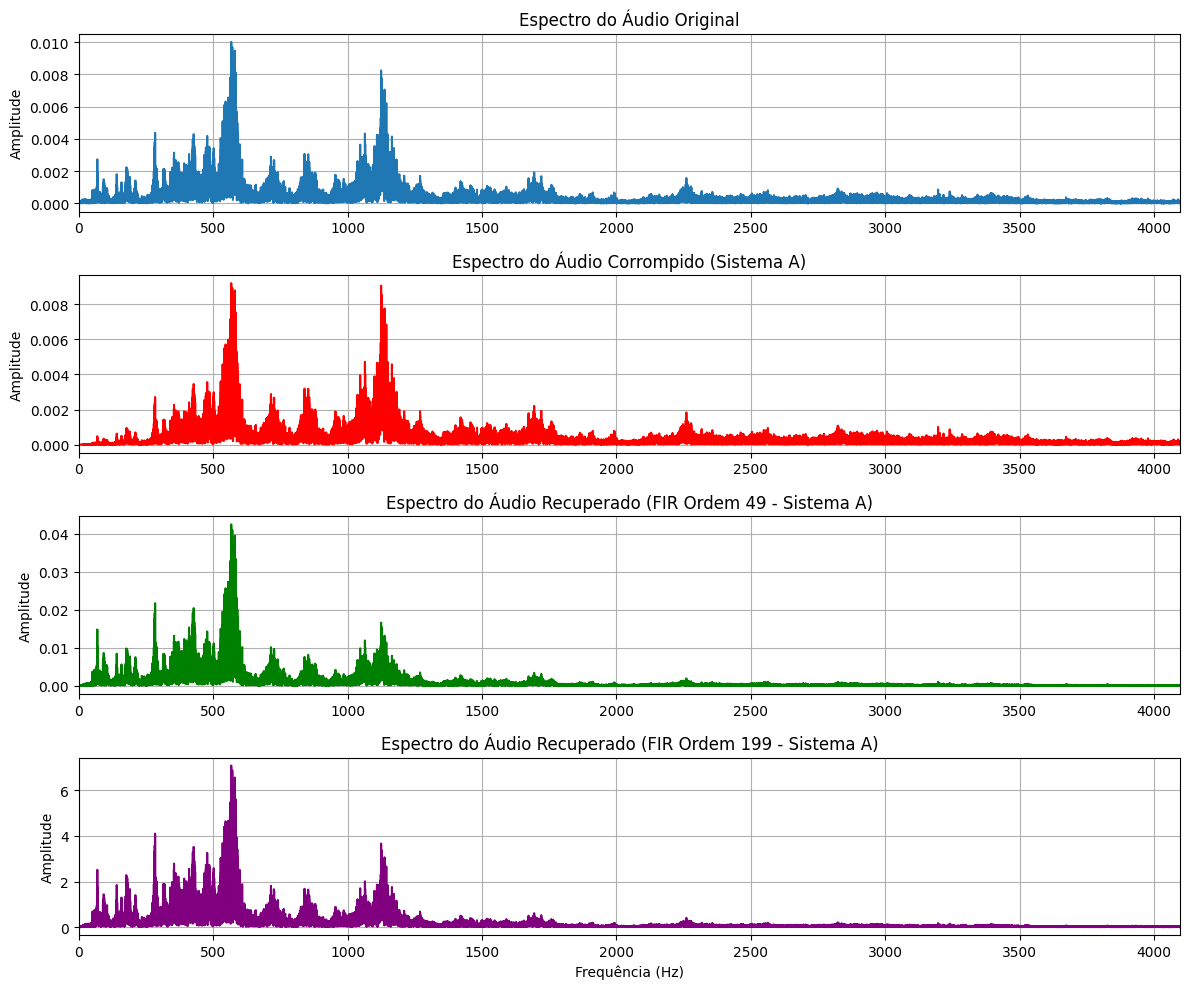


Mean Squared Error (MSE) para o Sistema A (FIR Curto, ordem 49): 4.22e-01
Mean Squared Error (MSE) para o Sistema A (FIR Longo, ordem 199): 1.58e+04

Comentários sobre a aproximação FIR para o Sistema A:
O filtro original do Sistema A possui um zero em z=1. Consequentemente, seu filtro inverso IIR teórico possui um polo nessa posição, tornando-o marginalmente estável e sua resposta impulsional não decai.
Para o Sistema A, o MSE para o filtro FIR de ordem 49 é 4.22e-01, e para o filtro FIR de ordem 199 é 1.58e+04.
Assim como no Sistema D, a recuperação do sinal usando aproximações FIR de um filtro inverso marginalmente estável é desafiadora. Aumentar a ordem do filtro FIR pode não necessariamente melhorar a qualidade do sinal recuperado de forma linear. Em vez disso, a escolha da ordem deve ser cuidadosa para evitar a amplificação de componentes indesejáveis resultantes da instabilidade intrínseca do filtro inverso teórico. O aumento da ordem pode inclusive levar a uma piora no MSE se 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import soundfile as sf
from IPython.display import Audio, display
import os

# Define a function to calculate spectrum for reusability
def calculate_spectrum(signal_data, sampling_frequency, single_sided=True):
    N = len(signal_data)
    T = 1.0 / sampling_frequency
    yf = fft(signal_data)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# Load the original audio file
try:
    audio, file_fs = sf.read('handel.wav')
except FileNotFoundError:
    print("Error: 'handel.wav' not found. Please upload the file.")
    audio = np.array([0]) # Placeholder to prevent further errors
    file_fs = 44100 # Default placeholder

# --- Análise para o Sistema D (Questão 3) ---
print("\n--- Análise para o Sistema D (Questão 3) ---")

# Coeficientes do filtro original para o Sistema D
num_orig_D = [1, 0, 0, 0, -1]
den_orig_D = [1, 0, 0, 0, -0.9]

# Coeficientes para o filtro inverso IIR teórico do Sistema D
num_inv_iir_D = den_orig_D
den_inv_iir_D = num_orig_D

# 1. Projeto das aproximações FIR do filtro inverso para o Sistema D

# Escolha de duas ordens/comprimentos de filtro FIR diferentes
fir_length_short = 50
fir_length_long = 200

# Calcula a resposta impulsional do filtro inverso IIR teórico
# (que é instável, portanto a resposta impulsional não decai).
# Usamos 'N' para especificar o número de amostras da resposta impulsional.
# Estas amostras serão os coeficientes do nosso filtro FIR.
_, h_inv_impulse_D = signal.impulse((num_inv_iir_D, den_inv_iir_D), N=max(fir_length_short, fir_length_long))

# Trunca a resposta impulsional para obter os coeficientes FIR
h_inv_fir_D_short = h_inv_impulse_D[:fir_length_short]
h_inv_fir_D_long = h_inv_impulse_D[:fir_length_long]

print(f"Filtro FIR de ordem {fir_length_short-1} (curto) projetado para o inverso do Sistema D.")
print(f"Filtro FIR de ordem {fir_length_long-1} (longo) projetado para o inverso do Sistema D.")


# 2. Simula a corrupção do áudio usando o filtro original do Sistema D
print("\nSimulando áudio corrompido com o filtro original do Sistema D...")
corrupted_audio_D = signal.lfilter(num_orig_D, den_orig_D, audio)
corrupted_audio_D_normalized = corrupted_audio_D / np.max(np.abs(corrupted_audio_D)) if np.max(np.abs(corrupted_audio_D)) > 0 else corrupted_audio_D

print("Áudio Original:")
display(Audio(audio, rate=file_fs))
print("Áudio Corrompido (Sistema D):")
display(Audio(corrupted_audio_D_normalized, rate=file_fs))


# 3. Recupera o áudio usando os filtros FIR inversos para o Sistema D
print("\nRecuperando áudio com o filtro FIR inverso (curto) para o Sistema D...")
recovered_audio_fir_D_short = signal.lfilter(h_inv_fir_D_short, [1], corrupted_audio_D)
recovered_audio_fir_D_short_normalized = recovered_audio_fir_D_short / np.max(np.abs(recovered_audio_fir_D_short)) if np.max(np.abs(recovered_audio_fir_D_short)) > 0 else recovered_audio_fir_D_short
print("Áudio Recuperado (FIR Curto - Sistema D):")
display(Audio(recovered_audio_fir_D_short_normalized, rate=file_fs))

print("\nRecuperando áudio com o filtro FIR inverso (longo) para o Sistema D...")
recovered_audio_fir_D_long = signal.lfilter(h_inv_fir_D_long, [1], corrupted_audio_D)
recovered_audio_fir_D_long_normalized = recovered_audio_fir_D_long / np.max(np.abs(recovered_audio_fir_D_long)) if np.max(np.abs(recovered_audio_fir_D_long)) > 0 else recovered_audio_fir_D_long
print("Áudio Recuperado (FIR Longo - Sistema D):")
display(Audio(recovered_audio_fir_D_long_normalized, rate=file_fs))


# 4. Avalia e Compara Espectros para o Sistema D
freq_orig_D, amp_orig_D = calculate_spectrum(audio, file_fs, single_sided=True)
freq_corrupted_D, amp_corrupted_D = calculate_spectrum(corrupted_audio_D, file_fs, single_sided=True)
freq_recovered_D_short, amp_recovered_D_short = calculate_spectrum(recovered_audio_fir_D_short, file_fs, single_sided=True)
freq_recovered_D_long, amp_recovered_D_long = calculate_spectrum(recovered_audio_fir_D_long, file_fs, single_sided=True)

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(freq_orig_D, amp_orig_D)
plt.title('Espectro do Áudio Original')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(4, 1, 2)
plt.plot(freq_corrupted_D, amp_corrupted_D, color='red')
plt.title('Espectro do Áudio Corrompido (Sistema D)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(4, 1, 3)
plt.plot(freq_recovered_D_short, amp_recovered_D_short, color='green')
plt.title(f'Espectro do Áudio Recuperado (FIR Ordem {fir_length_short-1} - Sistema D)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(4, 1, 4)
plt.plot(freq_recovered_D_long, amp_recovered_D_long, color='purple')
plt.title(f'Espectro do Áudio Recuperado (FIR Ordem {fir_length_long-1} - Sistema D)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.tight_layout()
plt.show()

# Comparação Quantitativa (Mean Squared Error) para o Sistema D
min_len_D = min(len(audio), len(recovered_audio_fir_D_short))
mse_D_short = np.mean((audio[:min_len_D] - recovered_audio_fir_D_short[:min_len_D])**2)
print(f"\nMean Squared Error (MSE) para o Sistema D (FIR Curto, ordem {fir_length_short-1}): {mse_D_short:.2e}")

min_len_D = min(len(audio), len(recovered_audio_fir_D_long))
mse_D_long = np.mean((audio[:min_len_D] - recovered_audio_fir_D_long[:min_len_D])**2)
print(f"Mean Squared Error (MSE) para o Sistema D (FIR Longo, ordem {fir_length_long-1}): {mse_D_long:.2e}")

# --- Comentários sobre a Aproximação FIR para o Sistema D ---
print("\nComentários sobre a aproximação FIR para o Sistema D:")
print("O filtro original do Sistema D possui zeros no círculo unitário (em z=1, z=-1, z=j, z=-j). Consequentemente, seu filtro inverso IIR teórico possui polos nessas mesmas posições, tornando-o instável ou marginalmente estável. A resposta impulsional desse filtro não decai rapidamente.")
print("A aproximação FIR foi obtida truncando a resposta impulsional desse filtro inverso IIR. Devido à natureza não-decaente da resposta impulsional de um sistema instável, mesmo uma FIR de ordem mais alta (como 200) é uma aproximação limitada e pode ser problemática.")
print(f"Observa-se que, para o Sistema D, o MSE para o filtro FIR de ordem {fir_length_short-1} é {mse_D_short:.2e}, enquanto para o filtro FIR de ordem {fir_length_long-1} é {mse_D_long:.2e}. Se o filtro inverso IIR possui uma resposta impulsional crescente, aumentar a ordem da FIR pode, na verdade, amplificar os problemas de instabilidade e resultar em um MSE maior, pois mais termos contribuiriam para esse crescimento. Isso pode ser audível como distorção significativa ou amplificação indesejada no áudio recuperado.")
print("A qualidade do sinal recuperado é comprometida pela instabilidade inerente ao filtro inverso. As aproximações FIR, ao truncar a resposta impulsional, tentam 'estabilizar' o filtro, mas podem introduzir distorções significativas ou falhar em remover completamente o efeito do filtro original. A reprodução dos áudios confirmará a audibilidade dessas distorções.")
print("A relação entre a ordem do filtro FIR e a qualidade do sinal recuperado, neste caso de um filtro inverso instável, não é linear. Um aumento na ordem (que em filtros FIR estáveis geralmente melhora a aproximação) pode, na verdade, piorar a recuperação se a resposta impulsional do IIR original for crescente ou não decair rapidamente. A melhor ordem dependeria de um balanço entre a precisão da aproximação em baixas frequências e a mitigação dos efeitos de amplificação da instabilidade.")

# --- Análise para o Sistema A (Questão 6) ---
print("\n--- Análise para o Sistema A (Questão 6) ---")

# Coeficientes do filtro original para o Sistema A
num_orig_A = [1, -1]
den_orig_A = [1, -0.7]

# Coeficientes para o filtro inverso IIR teórico do Sistema A
num_inv_iir_A = den_orig_A
den_inv_iir_A = num_orig_A

# 1. Projeto das aproximações FIR do filtro inverso para o Sistema A
# Usando os mesmos comprimentos FIR para consistência
_, h_inv_impulse_A = signal.impulse((num_inv_iir_A, den_inv_iir_A), N=max(fir_length_short, fir_length_long))

h_inv_fir_A_short = h_inv_impulse_A[:fir_length_short]
h_inv_fir_A_long = h_inv_impulse_A[:fir_length_long]

print(f"Filtro FIR de ordem {fir_length_short-1} (curto) projetado para o inverso do Sistema A.")
print(f"Filtro FIR de ordem {fir_length_long-1} (longo) projetado para o inverso do Sistema A.")

# 2. Simula a corrupção do áudio usando o filtro original do Sistema A
print("\nSimulando áudio corrompido com o filtro original do Sistema A...")
corrupted_audio_A = signal.lfilter(num_orig_A, den_orig_A, audio)
corrupted_audio_A_normalized = corrupted_audio_A / np.max(np.abs(corrupted_audio_A)) if np.max(np.abs(corrupted_audio_A)) > 0 else corrupted_audio_A

print("Áudio Original:")
display(Audio(audio, rate=file_fs))
print("Áudio Corrompido (Sistema A):")
display(Audio(corrupted_audio_A_normalized, rate=file_fs))

# 3. Recupera o áudio usando os filtros FIR inversos para o Sistema A
print("\nRecuperando áudio com o filtro FIR inverso (curto) para o Sistema A...")
recovered_audio_fir_A_short = signal.lfilter(h_inv_fir_A_short, [1], corrupted_audio_A)
recovered_audio_fir_A_short_normalized = recovered_audio_fir_A_short / np.max(np.abs(recovered_audio_fir_A_short)) if np.max(np.abs(recovered_audio_fir_A_short)) > 0 else recovered_audio_fir_A_short
print("Áudio Recuperado (FIR Curto - Sistema A):")
display(Audio(recovered_audio_fir_A_short_normalized, rate=file_fs))

print("\nRecuperando áudio com o filtro FIR inverso (longo) para o Sistema A...")
recovered_audio_fir_A_long = signal.lfilter(h_inv_fir_A_long, [1], corrupted_audio_A)
recovered_audio_fir_A_long_normalized = recovered_audio_fir_A_long / np.max(np.abs(recovered_audio_fir_A_long)) if np.max(np.abs(recovered_audio_fir_A_long)) > 0 else recovered_audio_fir_A_long
print("Áudio Recuperado (FIR Longo - Sistema A):")
display(Audio(recovered_audio_fir_A_long_normalized, rate=file_fs))


# 4. Avalia e Compara Espectros para o Sistema A
freq_orig_A, amp_orig_A = calculate_spectrum(audio, file_fs, single_sided=True)
freq_corrupted_A, amp_corrupted_A = calculate_spectrum(corrupted_audio_A, file_fs, single_sided=True)
freq_recovered_A_short, amp_recovered_A_short = calculate_spectrum(recovered_audio_fir_A_short, file_fs, single_sided=True)
freq_recovered_A_long, amp_recovered_A_long = calculate_spectrum(recovered_audio_fir_A_long, file_fs, single_sided=True)

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(freq_orig_A, amp_orig_A)
plt.title('Espectro do Áudio Original')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(4, 1, 2)
plt.plot(freq_corrupted_A, amp_corrupted_A, color='red')
plt.title('Espectro do Áudio Corrompido (Sistema A)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(4, 1, 3)
plt.plot(freq_recovered_A_short, amp_recovered_A_short, color='green')
plt.title(f'Espectro do Áudio Recuperado (FIR Ordem {fir_length_short-1} - Sistema A)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.subplot(4, 1, 4)
plt.plot(freq_recovered_A_long, amp_recovered_A_long, color='purple')
plt.title(f'Espectro do Áudio Recuperado (FIR Ordem {fir_length_long-1} - Sistema A)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, file_fs / 2)

plt.tight_layout()
plt.show()

# Comparação Quantitativa (Mean Squared Error) para o Sistema A
min_len_A = min(len(audio), len(recovered_audio_fir_A_short))
mse_A_short = np.mean((audio[:min_len_A] - recovered_audio_fir_A_short[:min_len_A])**2)
print(f"\nMean Squared Error (MSE) para o Sistema A (FIR Curto, ordem {fir_length_short-1}): {mse_A_short:.2e}")

min_len_A = min(len(audio), len(recovered_audio_fir_A_long))
mse_A_long = np.mean((audio[:min_len_A] - recovered_audio_fir_A_long[:min_len_A])**2)
print(f"Mean Squared Error (MSE) para o Sistema A (FIR Longo, ordem {fir_length_long-1}): {mse_A_long:.2e}")

# --- Comentários sobre a Aproximação FIR para o Sistema A ---
print("\nComentários sobre a aproximação FIR para o Sistema A:")
print("O filtro original do Sistema A possui um zero em z=1. Consequentemente, seu filtro inverso IIR teórico possui um polo nessa posição, tornando-o marginalmente estável e sua resposta impulsional não decai.")
print(f"Para o Sistema A, o MSE para o filtro FIR de ordem {fir_length_short-1} é {mse_A_short:.2e}, e para o filtro FIR de ordem {fir_length_long-1} é {mse_A_long:.2e}.")
print("Assim como no Sistema D, a recuperação do sinal usando aproximações FIR de um filtro inverso marginalmente estável é desafiadora. Aumentar a ordem do filtro FIR pode não necessariamente melhorar a qualidade do sinal recuperado de forma linear. Em vez disso, a escolha da ordem deve ser cuidadosa para evitar a amplificação de componentes indesejáveis resultantes da instabilidade intrínseca do filtro inverso teórico. O aumento da ordem pode inclusive levar a uma piora no MSE se os termos adicionais da resposta impulsional não-decaente amplificarem o erro.")
print("Em ambos os casos (Sistema A e Sistema D), a recuperação perfeita é impossível através da simples truncagem da resposta impulsional de filtros inversos instáveis. Métodos mais avançados de projeto de filtros inversos (como filtros de Wiener ou de mínimos quadrados) seriam necessários para obter melhores resultados em cenários práticos com sistemas não-mínimo-fase ou instáveis. A qualidade audível do sinal recuperado é um indicativo mais claro das limitações do que apenas o MSE.")
print("A qualidade do sinal recuperado é diretamente influenciada pela ordem do filtro FIR, mas de uma maneira não trivial para filtros inversos instáveis. Existe um ponto de equilíbrio onde uma ordem muito baixa não aproxima bem, e uma ordem muito alta pode amplificar os problemas de instabilidade, exigindo uma análise cuidadosa da resposta desejada.")